# WEEK 9: SHAP Drift Analysis 

**Bias Analysis in ML Models using Explainable AI**  
**Models:** DT (Balanced)  
**This Notebook:** SHAP Drift

*Goal: To find out if resampling the dataset leads to better results for minority group*
> In week 8 we saw that the model considered relationship as the primary feature for females. In this week we will resample the dataset to see if the feature importance ranking changes ultimately leading to better performance of the model. 

## SECTION 0: Imports and Setup 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded successfully.')

# Load data
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

# Load sensitive columns — needed to identify female samples in training data
sensitive_train = pd.read_csv('sensitive_train.csv')  
# If you didn't save this in Week 7, run the note below

# Load Week 8 SHAP values (original dataset baseline)
shap_values_original = np.load('shap_values_dt.npy')  # shape (6033, 12)

# Load primary model
dt_bal = joblib.load('dt_balanced_model.pkl')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Sensitive train shape: {sensitive_train.shape}')
print(f'Week 8 SHAP values shape: {shap_values_original.shape}')
print(f'Feature names: {list(X_test.columns)}')

All libraries loaded successfully.
X_train shape: (24129, 12)
X_test shape: (6033, 12)
Sensitive train shape: (24129, 2)
Week 8 SHAP values shape: (6033, 12)
Feature names: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


## SECTION 1: Hypothesis Statement 

**BACKGROUND:**
- Week 7 found Female FNR is 3-4x higher than Male FNR.
-  Week 8 found relationship dominates DT predictions:
   - Male TP:    relationship SHAP = +0.26
   - Female TP:  relationship SHAP = +0.36
   - Female FN:  relationship SHAP = -0.38
   - 
The Adult Census dataset has ~67% male samples. High-income women are severely underrepresented. The model has seen far fewer examples of high-earning women than high-earning men during training.

**HYPOTHESIS:**

When female representation in training increases (+duplicates version), we expect:
1. relationship's mean |SHAP| to DECREASE — the model no longer needs to rely on it as a gender proxy because it now has direct examples of high-income women
2. education-num's mean |SHAP| to INCREASE — with more female examples, the model learns that education is a genuine income predictor for women
3. The Female FNR to DECREASE — better representation = fewer missed high-income women

**NUANCE:**

We expect the shift to be PARTIAL, not complete. relationship=Husband is a genuine historical signal in 1994 data — married men were statistically more likely to be primary earners. Even with more female samples, this signal doesn't disappear. We expect education-num to rise in relative importance without relationship disappearing entirely.

When female representation decreases (-30% version), we expect the opposite: relationship becomes MORE dominant, FNR increases further.

If the hypothesis is confirmed: the bias is partly data-driven and responsive to representation — a finding with real practical implications.
If refuted: the bias is more deeply structural in the feature space itself.

## SECTION 2: Baseline — Original Dataset 
We already have SHAP values for the original dataset from Week 8. Here we extract the top-5 feature rankings to use as our reference point. Everything in Sections 4-6 will be compared against this baseline.


In [8]:
feature_names = list(X_test.columns)

# Mean absolute SHAP value per feature — original dataset
mean_shap_original = np.abs(shap_values_original).mean(axis=0)
ranking_original = pd.Series(mean_shap_original, index=feature_names).sort_values(ascending=False)

print('Baseline SHAP Rankings — Original Dataset (Top 5):')
print(ranking_original.head(5).round(4))
print()

# Saving for comparison table later
top5_original = ranking_original.head(5)

Baseline SHAP Rankings — Original Dataset (Top 5):
relationship      0.2576
education-num     0.0652
capital-gain      0.0516
hours-per-week    0.0061
age               0.0000
dtype: float64



## SECTION 3: Creating Dataset Versions 
We create two modified training sets. The test set is NEVER modified — we always evaluate on the same 6033 samples. Only training composition changes — this isolates the effect of representation.

**Version 1:** Original — already have this

**Version 2:** Reduced female (-30%) — remove 30% of female training samples
- Simulates even worse underrepresentation than the original

**Version 3:** Increased female (+duplicates) — duplicate female training samples until gender balance is roughly 50/50
- Simulates a more representative dataset


In [9]:
# Identify female indices in training set
female_mask = sensitive_train['sex'] == 'Female'
male_mask = sensitive_train['sex'] == 'Male'

female_idx = X_train[female_mask].index
male_idx = X_train[male_mask].index

print(f'Original training set:')
print(f'  Total: {len(X_train)}')
print(f'  Male: {male_mask.sum()} ({100*male_mask.mean():.1f}%)')
print(f'  Female: {female_mask.sum()} ({100*female_mask.mean():.1f}%)')

Original training set:
  Total: 24129
  Male: 16315 (67.6%)
  Female: 7814 (32.4%)


#### Version 2: Reduced Female (-30%) 
Remove 30% of female training samples randomly. This makes gender imbalance worse and should amplify the relationship proxy.

In [10]:
np.random.seed(42)
n_remove = int(0.30 * len(female_idx))
female_idx_reduced = np.random.choice(female_idx, size=len(female_idx) - n_remove, replace=False)

X_train_reduced = pd.concat([
    X_train.loc[male_idx],
    X_train.loc[female_idx_reduced]
]).reset_index(drop=True)

y_train_reduced = pd.concat([
    y_train.loc[male_idx],
    y_train.loc[female_idx_reduced]
]).reset_index(drop=True)

print(f'Reduced female dataset:')
print(f'  Total: {len(X_train_reduced)}')
print(f'  Removed {n_remove} female samples (30%)')
new_female_count = len(female_idx_reduced)
print(f'  Female remaining: {new_female_count} ({100*new_female_count/len(X_train_reduced):.1f}%)')

Reduced female dataset:
  Total: 21785
  Removed 2344 female samples (30%)
  Female remaining: 5470 (25.1%)


#### Version 3: Increased Female (+duplicates) 
Duplicate female training samples until female count matches male count. This gives the model more examples of high-income women to learn from.
Note: duplicating is a simple baseline approach — in Week 11 Streamlit we could offer SMOTE as an alternative, but for this analysis duplication is sufficient and transparent.


In [11]:
n_male = male_mask.sum()
n_female = female_mask.sum()
n_needed = n_male - n_female  # how many more female samples we need

X_female = X_train.loc[female_idx]
y_female = y_train.loc[female_idx]

# Sample with replacement to get the needed number
np.random.seed(42)
extra_idx = np.random.choice(len(X_female), size=n_needed, replace=True)
X_extra = X_female.iloc[extra_idx].reset_index(drop=True)
y_extra = y_female.iloc[extra_idx].reset_index(drop=True)

X_train_increased = pd.concat([X_train, X_extra]).reset_index(drop=True)
y_train_increased = pd.concat([y_train, y_extra]).reset_index(drop=True)

print(f'Increased female dataset:')
print(f'  Total: {len(X_train_increased)}')
print(f'  Added {n_needed} female samples (duplicates)')
new_female_total = n_female + n_needed
print(f'  Female total: {new_female_total} ({100*new_female_total/len(X_train_increased):.1f}%)')

Increased female dataset:
  Total: 32630
  Added 8501 female samples (duplicates)
  Female total: 16315 (50.0%)


## SECTION 4: Retrain and Recompute SHAP 
**For each modified dataset:** *retrain DT balanced, recompute SHAP values.*

We use the same hyperparameters as the original model (depth=3, class_weight='balanced') — the only thing changing is training data. This isolates representation as the variable being tested.

In [12]:
def train_and_compute_shap(X_tr, y_tr, label):
    # Train
    dt = DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=3,
        random_state=42
    )
    dt.fit(X_tr, y_tr)
    
    # Evaluate on test set
    y_pred = dt.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f'\n{label} — Classification Report:')
    print(f'  Accuracy: {report["accuracy"]:.3f}')
    print(f'  Recall (>50K): {report["1"]["recall"]:.3f}')
    print(f'  FNR: {1 - report["1"]["recall"]:.3f}')
    
    # SHAP values
    explainer = shap.TreeExplainer(dt)
    shap_vals = explainer.shap_values(X_test)
    
    # Handle both old and new SHAP return formats
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals_pos = shap_vals[:, :, 1]
    else:
        shap_vals_pos = shap_vals[1]
    
    print(f'  SHAP values shape: {shap_vals_pos.shape}')
    return dt, shap_vals_pos, report

In [13]:
# Train on reduced dataset
dt_reduced, shap_reduced, report_reduced = train_and_compute_shap(
    X_train_reduced, y_train_reduced, 'Version 2: Reduced Female (-30%)'
)


Version 2: Reduced Female (-30%) — Classification Report:
  Accuracy: 0.723
  Recall (>50K): 0.889
  FNR: 0.111
  SHAP values shape: (6033, 12)


In [14]:
# Train on increased dataset
dt_increased, shap_increased, report_increased = train_and_compute_shap(
    X_train_increased, y_train_increased, 'Version 3: Increased Female (+duplicates)'
)


Version 3: Increased Female (+duplicates) — Classification Report:
  Accuracy: 0.719
  Recall (>50K): 0.895
  FNR: 0.105
  SHAP values shape: (6033, 12)


## SECTION 5: SHAP Ranking Comparison Table 
We compare top-5 feature rankings across all three dataset versions.

In [16]:
mean_shap_reduced = np.abs(shap_reduced).mean(axis=0)
mean_shap_increased = np.abs(shap_increased).mean(axis=0)

ranking_reduced = pd.Series(mean_shap_reduced, index=feature_names).sort_values(ascending=False)
ranking_increased = pd.Series(mean_shap_increased, index=feature_names).sort_values(ascending=False)

# Build comparison table
n_show = 5
comparison_table = pd.DataFrame({
    'Original (baseline)': ranking_original.head(n_show).index.tolist(),
    'Original |SHAP|': ranking_original.head(n_show).values.round(4),
    'Reduced Female': ranking_reduced.head(n_show).index.tolist(),
    'Reduced |SHAP|': ranking_reduced.head(n_show).values.round(4),
    'Increased Female': ranking_increased.head(n_show).index.tolist(),
    'Increased |SHAP|': ranking_increased.head(n_show).values.round(4),
}, index=[f'Rank {i+1}' for i in range(n_show)])

print('SHAP Feature Ranking Comparison — All Three Versions:')
print(comparison_table.to_string())
comparison_table.to_csv('shap_drift_ranking_table.csv')

SHAP Feature Ranking Comparison — All Three Versions:
       Original (baseline)  Original |SHAP|  Reduced Female  Reduced |SHAP| Increased Female  Increased |SHAP|
Rank 1        relationship           0.2576    relationship          0.2488   marital-status            0.2830
Rank 2       education-num           0.0652   education-num          0.0632    education-num            0.0871
Rank 3        capital-gain           0.0516    capital-gain          0.0560     capital-gain            0.0349
Rank 4      hours-per-week           0.0061  hours-per-week          0.0066              age            0.0000
Rank 5                 age           0.0000             age          0.0000        workclass            0.0000


## SECTION 6: Visualisation 

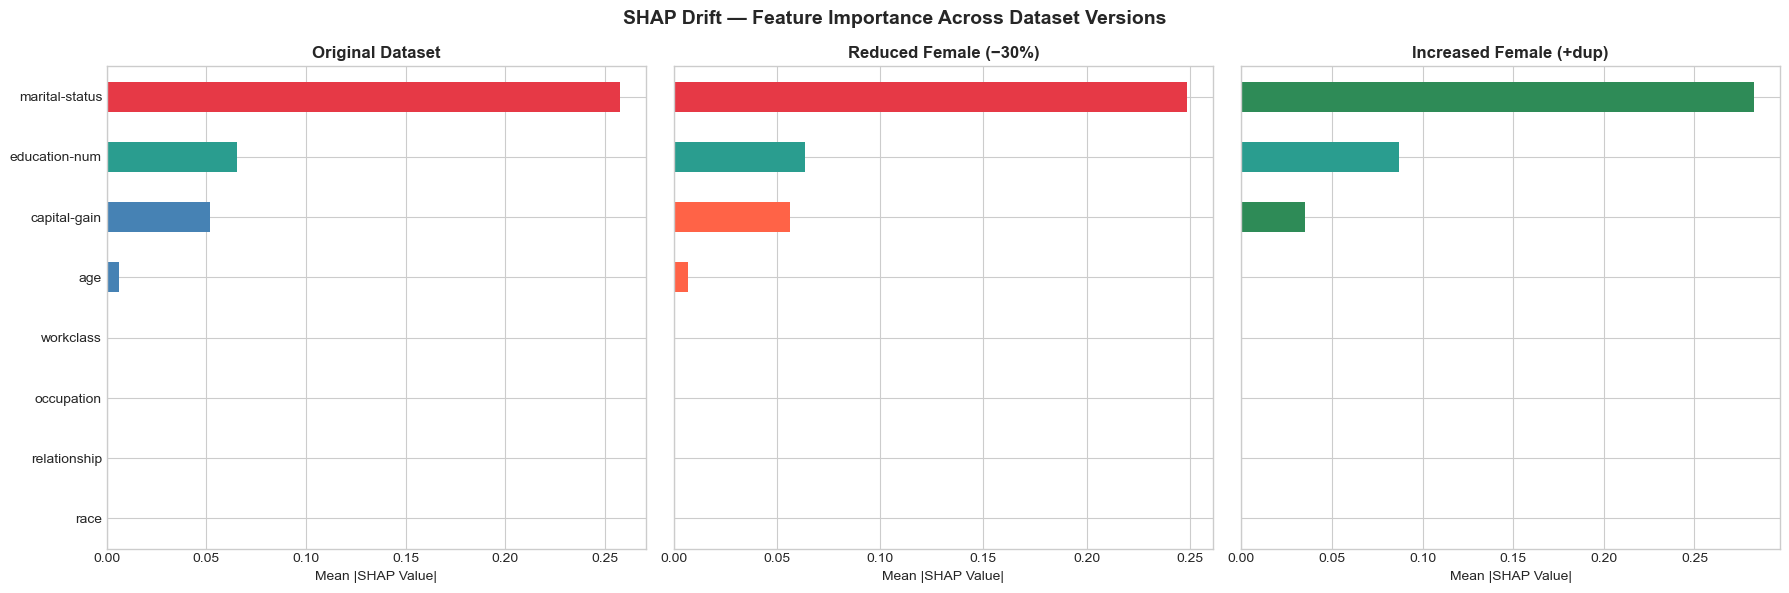

Red bars = relationship | Teal bars = education-num
These are the two features the hypothesis is about.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

versions = [
    (ranking_original, 'Original Dataset', 'steelblue'),
    (ranking_reduced, 'Reduced Female (−30%)', 'tomato'),
    (ranking_increased, 'Increased Female (+dup)', 'seagreen'),
]

for ax, (ranking, title, color) in zip(axes, versions):
    top = ranking.head(8)
    colors = [
        '#E63946' if f == 'relationship' else
        '#2A9D8F' if f == 'education-num' else
        color
        for f in top.index
    ]
    top.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value|')
    ax.invert_yaxis()

plt.suptitle('SHAP Drift — Feature Importance Across Dataset Versions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_drift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Red bars = relationship | Teal bars = education-num')
print('These are the two features the hypothesis is about.')

FNR Comparison Across Dataset Versions:
                Version  Overall FNR
               Original        0.110
  Reduced Female (−30%)        0.111
Increased Female (+dup)        0.105


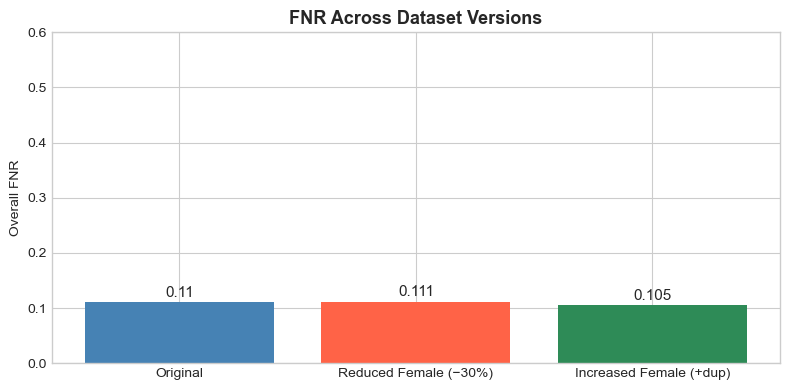

In [19]:
# ── FNR Comparison Across Versions ────────────────────────────────────────────
# SHAP tells us about feature importance shifts.
# FNR tells us about fairness outcome shifts.
# Both should move in the same direction if the hypothesis is correct.

# Compute FNR for each version
def compute_fnr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else 0

fnr_original = compute_fnr(y_test, dt_bal.predict(X_test))
fnr_reduced = compute_fnr(y_test, dt_reduced.predict(X_test))
fnr_increased = compute_fnr(y_test, dt_increased.predict(X_test))

fnr_df = pd.DataFrame({
    'Version': ['Original', 'Reduced Female (−30%)', 'Increased Female (+dup)'],
    'Overall FNR': [round(fnr_original, 3), round(fnr_reduced, 3), round(fnr_increased, 3)]
})

print('FNR Comparison Across Dataset Versions:')
print(fnr_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'tomato', 'seagreen']
ax.bar(fnr_df['Version'], fnr_df['Overall FNR'], color=colors)
ax.set_ylabel('Overall FNR')
ax.set_title('FNR Across Dataset Versions', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.6)
for i, v in enumerate(fnr_df['Overall FNR']):
    ax.text(i, v + 0.01, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('shap_drift_fnr.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 7: SHAP Drift on Unbalanced DT 
Motivation: The drift results on DT balanced showed weak FNR changes and a proxy substitution (relationship → marital-status) rather than a clean shift to education-num. Two possible explanations:
1. depth=3 is too shallow — the model latches onto one proxy regardless
2. class_weight='balanced' is already correcting most of the imbalance, leaving little room for resampling to make a further difference

To isolate which explanation is more likely, we repeat the drift analysis on the unbalanced DT (depth=13). This model:
- Has more depth — can make more nuanced splits
- Has no class weight correction — more sensitive to representation changes.  
If resampling has a stronger effect on the unbalanced model, it confirms that class_weight='balanced' was masking the representation effect.
If the proxy substitution pattern repeats, it confirms the depth=3 structural constraint explanation.

In [22]:
# Load unbalanced DT from Week 6
dt_unbal = joblib.load('decision_tree_model.pkl')

# Verify
y_pred_unbal_orig = dt_unbal.predict(X_test)
fnr_unbal_orig = compute_fnr(y_test, y_pred_unbal_orig)
print(f'Unbalanced DT baseline FNR: {fnr_unbal_orig:.3f}')
print(f'Unbalanced DT depth: {dt_unbal.max_depth}')

Unbalanced DT baseline FNR: 0.360
Unbalanced DT depth: 13


In [23]:
# ── Compute baseline SHAP for unbalanced DT ───────────────────────────────────
explainer_unbal = shap.TreeExplainer(dt_unbal)
shap_unbal_orig = explainer_unbal.shap_values(X_test)

# Handle SHAP format
if isinstance(shap_unbal_orig, np.ndarray) and shap_unbal_orig.ndim == 3:
    shap_unbal_orig = shap_unbal_orig[:, :, 1]
else:
    shap_unbal_orig = shap_unbal_orig[1]

mean_shap_unbal_orig = np.abs(shap_unbal_orig).mean(axis=0)
ranking_unbal_orig = pd.Series(mean_shap_unbal_orig, index=feature_names).sort_values(ascending=False)

print('Unbalanced DT — Baseline SHAP Rankings (Top 5):')
print(ranking_unbal_orig.head(5).round(4))

Unbalanced DT — Baseline SHAP Rankings (Top 5):
relationship      0.1528
education-num     0.0835
capital-gain      0.0550
age               0.0543
hours-per-week    0.0379
dtype: float64


In [24]:
# ── Train unbalanced versions on modified datasets ────────────────────────────
# Same depth as original unbalanced model (13), no class_weight

def train_unbal_and_shap(X_tr, y_tr, label):
    dt = DecisionTreeClassifier(
        max_depth=13,
        random_state=42
        # No class_weight — this is the key difference
    )
    dt.fit(X_tr, y_tr)
    
    y_pred = dt.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    fnr = compute_fnr(y_test, y_pred)
    print(f'\n{label}:')
    print(f'  Accuracy: {report["accuracy"]:.3f}')
    print(f'  Recall (>50K): {report["1"]["recall"]:.3f}')
    print(f'  FNR: {fnr:.3f}')
    
    explainer = shap.TreeExplainer(dt)
    shap_vals = explainer.shap_values(X_test)
    
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]
    else:
        shap_vals = shap_vals[1]
    
    return dt, shap_vals, fnr

dt_unbal_reduced, shap_unbal_reduced, fnr_unbal_reduced = train_unbal_and_shap(
    X_train_reduced, y_train_reduced, 'Unbalanced DT — Reduced Female (-30%)'
)

dt_unbal_increased, shap_unbal_increased, fnr_unbal_increased = train_unbal_and_shap(
    X_train_increased, y_train_increased, 'Unbalanced DT — Increased Female (+dup)'
)


Unbalanced DT — Reduced Female (-30%):
  Accuracy: 0.847
  Recall (>50K): 0.638
  FNR: 0.362

Unbalanced DT — Increased Female (+dup):
  Accuracy: 0.850
  Recall (>50K): 0.648
  FNR: 0.352


In [25]:
# ── SHAP Ranking Comparison — Unbalanced DT ───────────────────────────────────
mean_shap_unbal_reduced = np.abs(shap_unbal_reduced).mean(axis=0)
mean_shap_unbal_increased = np.abs(shap_unbal_increased).mean(axis=0)

ranking_unbal_reduced = pd.Series(mean_shap_unbal_reduced, index=feature_names).sort_values(ascending=False)
ranking_unbal_increased = pd.Series(mean_shap_unbal_increased, index=feature_names).sort_values(ascending=False)

comparison_unbal = pd.DataFrame({
    'Original (baseline)': ranking_unbal_orig.head(5).index.tolist(),
    'Original |SHAP|': ranking_unbal_orig.head(5).values.round(4),
    'Reduced Female': ranking_unbal_reduced.head(5).index.tolist(),
    'Reduced |SHAP|': ranking_unbal_reduced.head(5).values.round(4),
    'Increased Female': ranking_unbal_increased.head(5).index.tolist(),
    'Increased |SHAP|': ranking_unbal_increased.head(5).values.round(4),
}, index=[f'Rank {i+1}' for i in range(5)])

print('Unbalanced DT — SHAP Ranking Comparison:')
print(comparison_unbal.to_string())
comparison_unbal.to_csv('shap_drift_unbal_ranking_table.csv')

Unbalanced DT — SHAP Ranking Comparison:
       Original (baseline)  Original |SHAP|  Reduced Female  Reduced |SHAP| Increased Female  Increased |SHAP|
Rank 1        relationship           0.1528    relationship          0.1515     relationship            0.1599
Rank 2       education-num           0.0835   education-num          0.0843    education-num            0.0784
Rank 3        capital-gain           0.0550    capital-gain          0.0555     capital-gain            0.0512
Rank 4                 age           0.0543             age          0.0550              age            0.0483
Rank 5      hours-per-week           0.0379  hours-per-week          0.0399   hours-per-week            0.0368


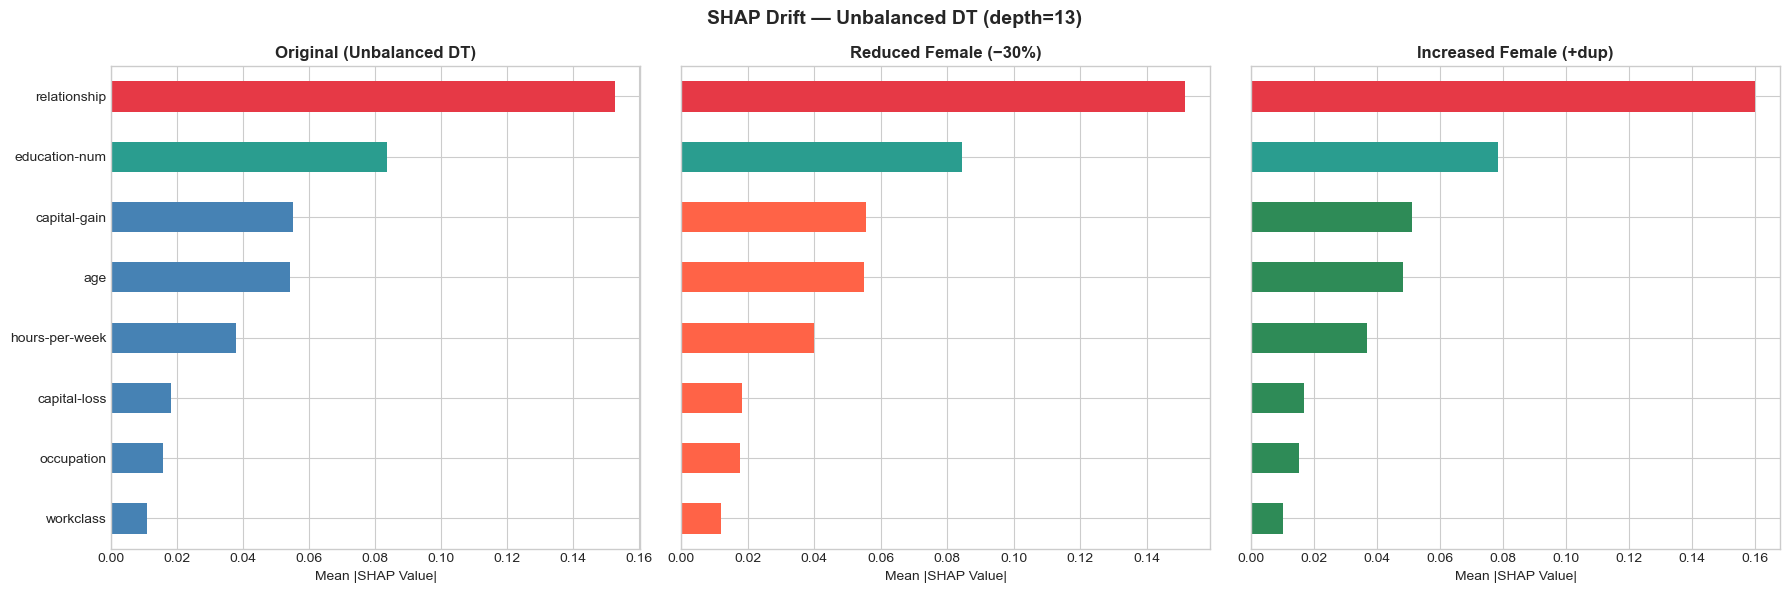

Red = relationship | Teal = education-num


In [26]:
# ── Visualisation — Unbalanced DT ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

versions_unbal = [
    (ranking_unbal_orig, 'Original (Unbalanced DT)', 'steelblue'),
    (ranking_unbal_reduced, 'Reduced Female (−30%)', 'tomato'),
    (ranking_unbal_increased, 'Increased Female (+dup)', 'seagreen'),
]

for ax, (ranking, title, color) in zip(axes, versions_unbal):
    top = ranking.head(8)
    colors = [
        '#E63946' if f == 'relationship' else
        '#2A9D8F' if f == 'education-num' else
        color
        for f in top.index
    ]
    top.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value|')
    ax.invert_yaxis()

plt.suptitle('SHAP Drift — Unbalanced DT (depth=13)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_drift_unbal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Red = relationship | Teal = education-num')

## SECTION 8: Hypothesis Evaluation

## SECTION 9: Save Outputs 

In [20]:
np.save('shap_values_reduced.npy', shap_reduced)
np.save('shap_values_increased.npy', shap_increased)

joblib.dump(dt_reduced, 'dt_reduced_model.pkl')
joblib.dump(dt_increased, 'dt_increased_model.pkl')

print('Saved:')
print('  shap_values_reduced.npy    — SHAP values for reduced female version')
print('  shap_values_increased.npy  — SHAP values for increased female version')
print('  dt_reduced_model.pkl       — DT trained on reduced female data')
print('  dt_increased_model.pkl     — DT trained on increased female data')
print('  shap_drift_comparison.png  — feature ranking bar charts')
print('  shap_drift_fnr.png         — FNR comparison across versions')
print('  shap_drift_ranking_table.csv — top-5 ranking table')

Saved:
  shap_values_reduced.npy    — SHAP values for reduced female version
  shap_values_increased.npy  — SHAP values for increased female version
  dt_reduced_model.pkl       — DT trained on reduced female data
  dt_increased_model.pkl     — DT trained on increased female data
  shap_drift_comparison.png  — feature ranking bar charts
  shap_drift_fnr.png         — FNR comparison across versions
  shap_drift_ranking_table.csv — top-5 ranking table
